In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import tensorflow as tf
import keras
from keras.layers import Input, Dense
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.layers import Dense, Dropout, SimpleRNN
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
val_performance = {}

In [ ]:
file_id = '1pkp_k-5KeywHZdg-joTNIkLL-R6ZVyAg'
download_url = f'https://drive.google.com/uc?export=download&id={file_id}'

print("Downloading PGCB dataset...")
df_raw = pd.read_csv(download_url)

df_raw['datetime'] = pd.to_datetime(df_raw['datetime'])
df_raw = df_raw.sort_values(by='datetime').reset_index(drop=True)

unnecessary_cols = [
    'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro',
    'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura',
    'india_adani', 'nepal', 'remarks', 'generation_mw'
]
df = df_raw.drop(columns=unnecessary_cols, errors='ignore')
print(f"Cleaned PGCB Dataset Base Shape: {df.shape}")

Cleaned PGCB Dataset Base Shape: (94934, 2)


In [ ]:
df['hour'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.month
# --- 5. Year Feature (Captures long-term load growth/trend) ---
df['year'] = df['datetime'].dt.year

df['Day_peak'] = df['hour'].apply(lambda x: 1 if 9 <= x < 17 else 0)
df['Evening_peak'] = df['hour'].apply(lambda x: 1 if 17 <= x < 23 else 0)
df['is_night'] = df['hour'].apply(lambda x: 1 if (x >= 23 or x < 6) else 0)


df['is_weekend'] = df['datetime'].dt.dayofweek.isin([4, 5]).astype(int)
df['is_weekday'] = df['datetime'].dt.dayofweek.isin([0, 1, 2, 3, 6]).astype(int)


# --- NEW: Bangladesh Power Grid Operational Seasons ---
def map_bd_power_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5, 6]:
        return "Summer"
    else:
        return "Monsoon"

# Map month to season
df["grid_season"] = df["month"].apply(map_bd_power_season)

# One-Hot Encode (Converts to purely numeric 0 and 1 columns)
df = pd.get_dummies(
    df, columns=["grid_season"], prefix="season", dtype=int, drop_first=False
)

# --- Autoregressive Lag Features ---
# 1-Hour Lag feature
df['demand_lag_1'] = df['demand_mw'].shift(1)

# 24-Hour Lag feature
# df['demand_lag_24'] = df['demand_mw'].shift(24)

df['demand_lag_168'] = df['demand_mw'].shift(168)




df_clean = df.dropna().reset_index(drop=True)
print(f"Dataset Shape after Feature Engineering & Cleaning: {df_clean.shape}")

Dataset Shape after Feature Engineering & Cleaning: (94766, 15)


In [ ]:
print("\n" + "="*50)
print("INITIAL EXPLORATORY DATA ANALYSIS (EDA)")
print("="*50)

print("\n--- 1. First 20 Rows ---")
display(df_clean.head(20))

print("\n--- 2. Dataset Information ---")
df_clean.info()

print("\n--- 3. Descriptive Statistics ---")
display(df_clean.describe())


INITIAL EXPLORATORY DATA ANALYSIS (EDA)

--- 1. First 20 Rows ---


,datetime,demand_mw,hour,month,year,Day_peak,Evening_peak,is_night,is_weekend,is_weekday,season_Monsoon,season_Summer,season_Winter,demand_lag_1,demand_lag_168
0,2015-04-27 09:00:00,5200,9,4,2015,1,0,0,0,1,0,1,0,4800.0,5862.0
1,2015-04-27 10:00:00,5430,10,4,2015,1,0,0,0,1,0,1,0,5200.0,6598.0
2,2015-04-27 11:00:00,5531,11,4,2015,1,0,0,0,1,0,1,0,5430.0,6639.0
3,2015-04-27 12:00:00,5602,12,4,2015,1,0,0,0,1,0,1,0,5531.0,6683.0
4,2015-04-27 13:00:00,5459,13,4,2015,1,0,0,0,1,0,1,0,5602.0,6782.0
5,2015-04-27 14:00:00,5424,14,4,2015,1,0,0,0,1,0,1,0,5459.0,6767.0
6,2015-04-27 15:00:00,5630,15,4,2015,1,0,0,0,1,0,1,0,5424.0,6491.0
7,2015-04-27 16:00:00,5569,16,4,2015,1,0,0,0,1,0,1,0,5630.0,6106.0
8,2015-04-27 17:00:00,5300,17,4,2015,0,1,0,0,1,0,1,0,5569.0,6106.0
9,2015-04-27 18:00:00,5194,18,4,2015,0,1,0,0,1,0,1,0,5300.0,4821.0



--- 2. Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94766 entries, 0 to 94765
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   datetime        94766 non-null  datetime64[ns]
 1   demand_mw       94766 non-null  int64         
 2   hour            94766 non-null  int32         
 3   month           94766 non-null  int32         
 4   year            94766 non-null  int32         
 5   Day_peak        94766 non-null  int64         
 6   Evening_peak    94766 non-null  int64         
 7   is_night        94766 non-null  int64         
 8   is_weekend      94766 non-null  int64         
 9   is_weekday      94766 non-null  int64         
 10  season_Monsoon  94766 non-null  int64         
 11  season_Summer   94766 non-null  int64         
 12  season_Winter   94766 non-null  int64         
 13  demand_lag_1    94766 non-null  float64       
 14  demand_lag_168  94766 

,datetime,demand_mw,hour,month,year,Day_peak,Evening_peak,is_night,is_weekend,is_weekday,season_Monsoon,season_Summer,season_Winter,demand_lag_1,demand_lag_168
count,94766,94766.000000,94766.000000,94766.000000,94766.000000,94766.000000,94766.000000,94766.000000,94766.000000,94766.000000,94766.000000,94766.000000,94766.000000,94766.000000,94766.000000
mean,2020-10-03 18:26:50.571301888,9013.156681,12.318553,6.585147,2020.251461,0.331870,0.295391,0.248380,0.285556,0.714444,0.426862,0.327575,0.245563,9013.068738,9001.155372
min,2015-04-27 09:00:00,6.000000,1.000000,1.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,6.000000
25%,2018-01-19 10:15:00,6931.000000,7.000000,4.000000,2018.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6931.000000,6919.000000
50%,2020-10-09 08:30:00,8639.000000,13.000000,7.000000,2020.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,8639.000000,8626.000000
75%,2023-06-24 20:45:00,10911.000000,18.000000,10.000000,2023.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,10911.000000,10900.000000
max,2026-03-08 23:00:00,156050.000000,23.000000,12.000000,2026.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,156050.000000,156050.000000
std,NaN,2833.822071,6.634948,3.437240,3.162878,0.470887,0.456221,0.432076,0.451681,0.451681,0.494625,0.469331,0.430423,2833.823502,2835.807791


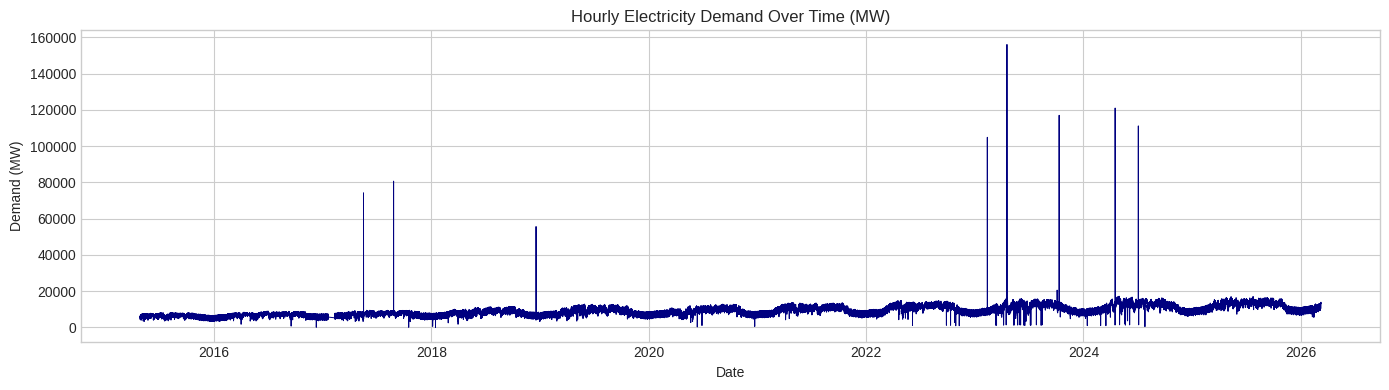

In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(df_clean['datetime'], df_clean['demand_mw'], color='navy', linewidth=0.7)
plt.title('Hourly Electricity Demand Over Time (MW)')
plt.ylabel('Demand (MW)')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

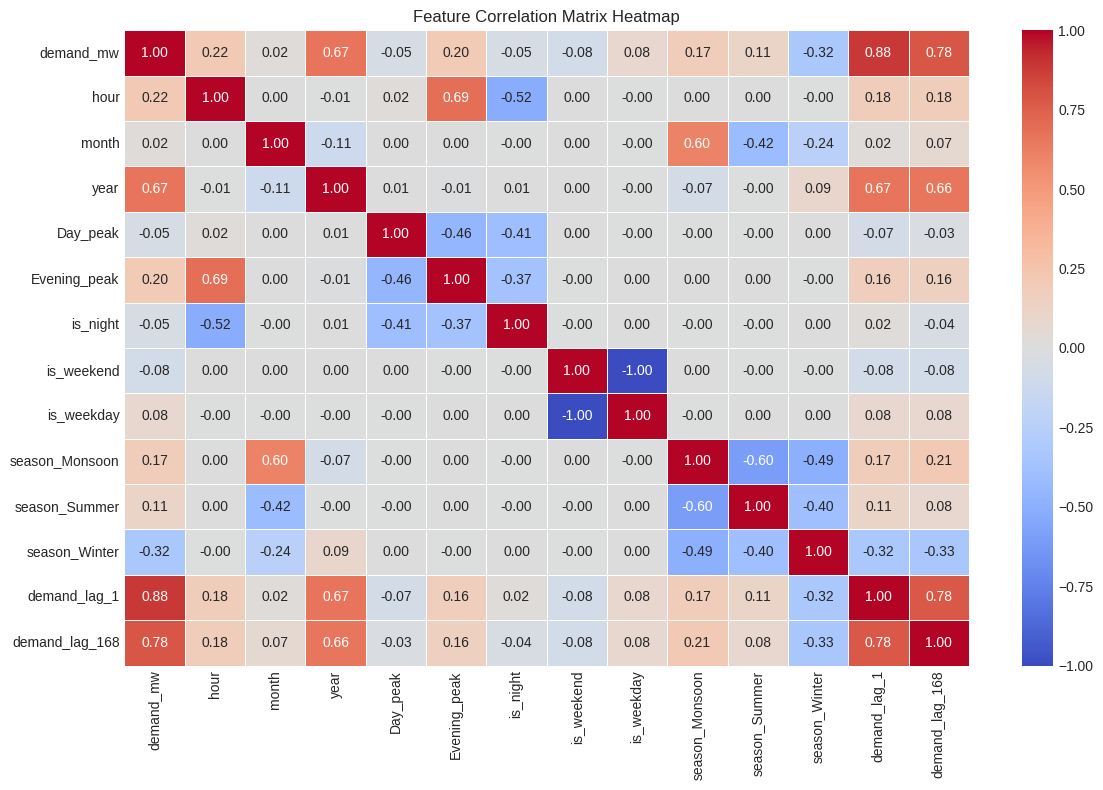

In [ ]:
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*50)
print("PREPROCESSING: CHRONOLOGICAL SPLIT & SCALING")
print("="*50)

target = 'demand_mw'
features = [col for col in df_clean.columns if col not in [target, 'datetime']]

# Training   : 2015 - 2020
# Validation : 2021 - 2022
# Testing    : 2023 - remaining years

train_mask = (
    (df_clean['datetime'].dt.year >= 2015) &
    (df_clean['datetime'].dt.year <= 2020)
)

val_mask = (
    (df_clean['datetime'].dt.year >= 2021) &
    (df_clean['datetime'].dt.year <= 2022)
)

test_mask = (
    df_clean['datetime'].dt.year >= 2023
)

X_train = df_clean.loc[train_mask, features]
y_train = df_clean.loc[train_mask, target]

X_val = df_clean.loc[val_mask, features]
y_val = df_clean.loc[val_mask, target]

X_test = df_clean.loc[test_mask, features]
y_test = df_clean.loc[test_mask, target]

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=features,
    index=X_train.index
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=features,
    index=X_val.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=features,
    index=X_test.index
)

scaler_y = StandardScaler()

y_train_scaled = scaler_y.fit_transform(
    y_train.values.reshape(-1, 1)
).flatten()

y_val_scaled = scaler_y.transform(
    y_val.values.reshape(-1, 1)
).flatten()

y_test_scaled = scaler_y.transform(
    y_test.values.reshape(-1, 1)
).flatten()


print("--- Chronological Split Summary ---")
print(f"Target Feature: '{target}'")
print(f"Input Features ({len(features)}): {features}")

print("\n--- Split Periods ---")
print("Training   : 2015 - 2020")
print("Validation : 2021 - 2022")
print("Testing    : 2023 - remaining years")

print("\n--- Dataset Shapes ---")
print(f"Train Set Shape:      {X_train_scaled.shape}")
print(f"Validation Set Shape: {X_val_scaled.shape}")
print(f"Test Set Shape:       {X_test_scaled.shape}")


PREPROCESSING: CHRONOLOGICAL SPLIT & SCALING
--- Chronological Split Summary ---
Target Feature: 'demand_mw'
Input Features (13): ['hour', 'month', 'year', 'Day_peak', 'Evening_peak', 'is_night', 'is_weekend', 'is_weekday', 'season_Monsoon', 'season_Summer', 'season_Winter', 'demand_lag_1', 'demand_lag_168']

--- Split Periods ---
Training   : 2015 - 2020
Validation : 2021 - 2022
Testing    : 2023 - remaining years

--- Dataset Shapes ---
Train Set Shape:      (49387, 13)
Validation Set Shape: (17498, 13)
Test Set Shape:       (27881, 13)


In [ ]:
print("\n" + "="*50)
print("FORECASTING EXPERIMENT SETUP")
print("="*50)

print("Training samples:   ", len(X_train_scaled))
print("Validation samples: ", len(X_val_scaled))
print("Testing samples:    ", len(X_test_scaled))

print("PREPROCESSING COMPLETE")
print("="*50)


FORECASTING EXPERIMENT SETUP
Training samples:    49387
Validation samples:  17498
Testing samples:     27881
PREPROCESSING COMPLETE


Linear Regression


SECTION 7: LINEAR REGRESSION
Linear Regression Training Complete.
➜ Validation RMSE: 523.43 MW
➜ Test RMSE      : 1977.33 MW
➜ Test R² Score  : 0.4959


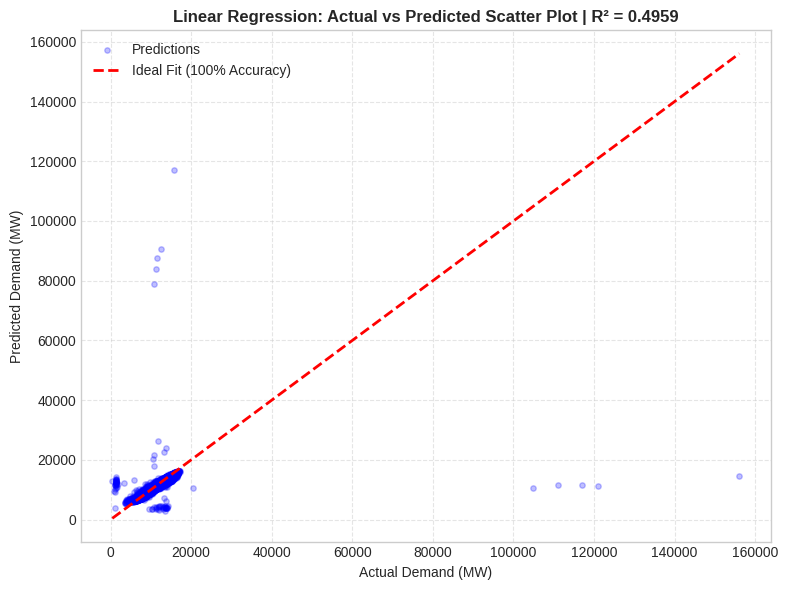

In [ ]:
# ==============================================================================
# SECTION 7: LINEAR REGRESSION (TRAIN, VAL, TEST & VISUALIZATION)
# ==============================================================================
print("\n" + "="*50)
print("SECTION 7: LINEAR REGRESSION")
print("="*50)

# 1. Train the model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_scaled)

# 2. Predict on VALIDATION SET
lr_preds_val_scaled = lr_model.predict(X_val_scaled)
lr_preds_val = scaler_y.inverse_transform(lr_preds_val_scaled.reshape(-1, 1)).flatten()

lr_val_rmse = np.sqrt(mean_squared_error(y_val, lr_preds_val))
val_performance['Linear Regression'] = lr_val_rmse
print(f"Linear Regression Training Complete.")
print(f"➜ Validation RMSE: {lr_val_rmse:.2f} MW")

# 3. Predict on TEST SET
lr_preds_test_scaled = lr_model.predict(X_test_scaled)
lr_preds_test = scaler_y.inverse_transform(lr_preds_test_scaled.reshape(-1, 1)).flatten()

lr_test_rmse = np.sqrt(mean_squared_error(y_test, lr_preds_test))
lr_test_r2 = r2_score(y_test, lr_preds_test)
print(f"➜ Test RMSE      : {lr_test_rmse:.2f} MW")
print(f"➜ Test R² Score  : {lr_test_r2:.4f}")

plt.figure(figsize=(8, 6))

# Scatter Plot (X: Actual, Y: Predicted)
plt.scatter(y_test, lr_preds_test, color='blue', alpha=0.25, s=15, label='Predictions')

# Reference Line for Ideal Fit (y = x)
min_val = min(y_test.min(), lr_preds_test.min())
max_val = max(y_test.max(), lr_preds_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Fit (100% Accuracy)')

plt.title(f'Linear Regression: Actual vs Predicted Scatter Plot | R² = {lr_test_r2:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Actual Demand (MW)', fontsize=10)
plt.ylabel('Predicted Demand (MW)', fontsize=10)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Random Forest


SECTION 8: RANDOM FOREST
Random Forest Training Complete.
➜ Validation RMSE: 610.89 MW
➜ Validation R²  : 0.9154
➜ Test RMSE      : 2069.43 MW
➜ Test R² Score  : 0.4478


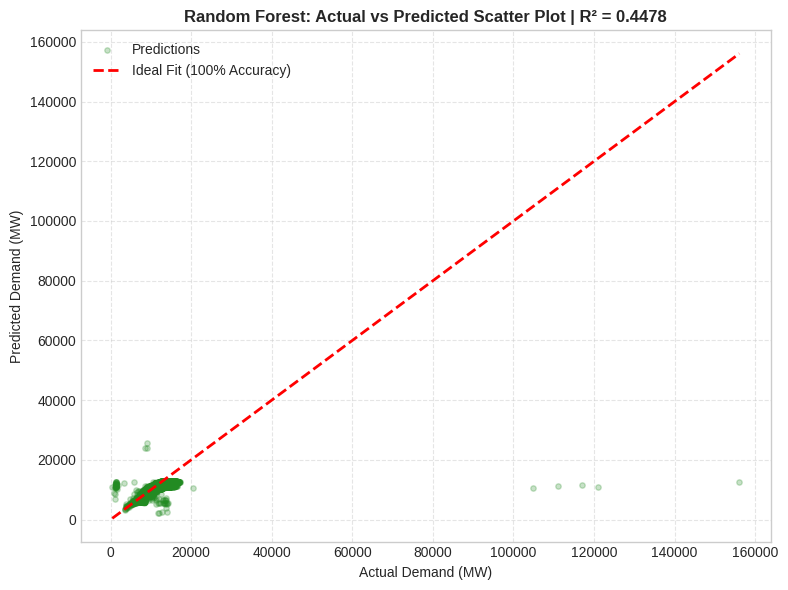

In [ ]:
# ==============================================================================
# SECTION 8: RANDOM FOREST (TRAIN, VAL, TEST & VISUALIZATION)
# ==============================================================================
print("\n" + "="*50)
print("SECTION 8: RANDOM FOREST")
print("="*50)

# 1. Train the model
rf_model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train_scaled)

# 2. Predict on VALIDATION SET
rf_preds_val_scaled = rf_model.predict(X_val_scaled)
rf_preds_val = scaler_y.inverse_transform(rf_preds_val_scaled.reshape(-1, 1)).flatten()

rf_val_rmse = np.sqrt(mean_squared_error(y_val, rf_preds_val))
rf_val_r2 = r2_score(y_val, rf_preds_val)
val_performance['Random Forest'] = rf_val_rmse

print("Random Forest Training Complete.")
print(f"➜ Validation RMSE: {rf_val_rmse:.2f} MW")
print(f"➜ Validation R²  : {rf_val_r2:.4f}")

# 3. Predict on TEST SET
rf_preds_test_scaled = rf_model.predict(X_test_scaled)
rf_preds_test = scaler_y.inverse_transform(rf_preds_test_scaled.reshape(-1, 1)).flatten()

rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_preds_test))
rf_test_r2 = r2_score(y_test, rf_preds_test)

print(f"➜ Test RMSE      : {rf_test_rmse:.2f} MW")
print(f"➜ Test R² Score  : {rf_test_r2:.4f}")

# 4. SCATTER PLOT: Actual vs Predicted for Random Forest (Test Set)
plt.figure(figsize=(8, 6))

# Scatter plot of actual vs predicted
plt.scatter(y_test, rf_preds_test, color='forestgreen', alpha=0.25, s=15, label='Predictions')

# Reference Line for 100% ideal fit (y = x)
min_val = min(y_test.min(), rf_preds_test.min())
max_val = max(y_test.max(), rf_preds_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Fit (100% Accuracy)')

plt.title(f'Random Forest: Actual vs Predicted Scatter Plot | R² = {rf_test_r2:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Actual Demand (MW)', fontsize=10)
plt.ylabel('Predicted Demand (MW)', fontsize=10)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

XGBoost


SECTION 9: XGBOOST
XGBoost Training Complete.
➜ Validation RMSE: 530.62 MW
➜ Validation R²  : 0.9361
➜ Test RMSE      : 2022.34 MW
➜ Test R² Score  : 0.4727


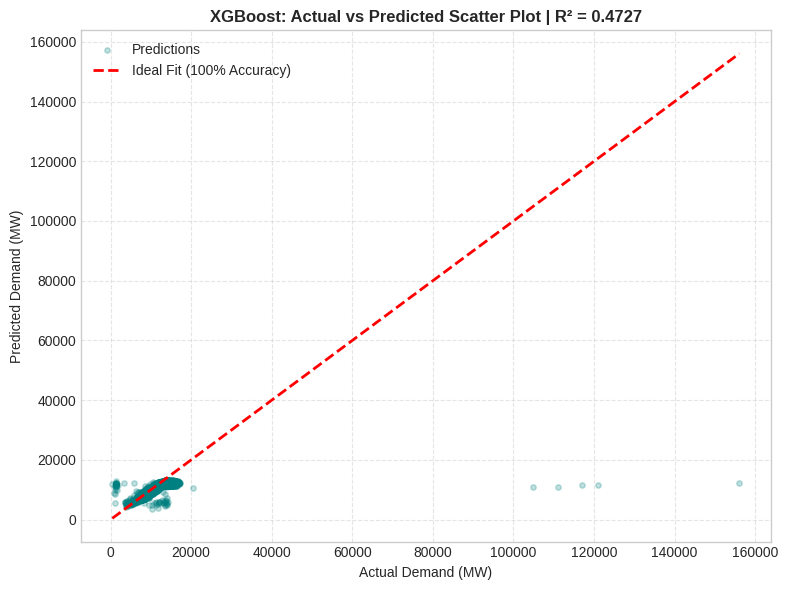

In [ ]:
# ==============================================================================
# SECTION 9: XGBOOST (TRAIN, VAL, TEST & VISUALIZATION)
# ==============================================================================
print("\n" + "="*50)
print("SECTION 9: XGBOOST")
print("="*50)

# 1. Train the model
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42, early_stopping_rounds=10)
xgb_model.fit(
    X_train_scaled, y_train_scaled,
    eval_set=[(X_val_scaled, y_val_scaled)],
    verbose=False
)

# 2. Predict on VALIDATION SET
xgb_preds_val_scaled = xgb_model.predict(X_val_scaled)
xgb_preds_val = scaler_y.inverse_transform(xgb_preds_val_scaled.reshape(-1, 1)).flatten()

xgb_val_rmse = np.sqrt(mean_squared_error(y_val, xgb_preds_val))
xgb_val_r2 = r2_score(y_val, xgb_preds_val)
val_performance['XGBoost'] = xgb_val_rmse

print("XGBoost Training Complete.")
print(f"➜ Validation RMSE: {xgb_val_rmse:.2f} MW")
print(f"➜ Validation R²  : {xgb_val_r2:.4f}")

# 3. Predict on TEST SET
xgb_preds_test_scaled = xgb_model.predict(X_test_scaled)
xgb_preds_test = scaler_y.inverse_transform(xgb_preds_test_scaled.reshape(-1, 1)).flatten()

xgb_test_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds_test))
xgb_test_r2 = r2_score(y_test, xgb_preds_test)

print(f"➜ Test RMSE      : {xgb_test_rmse:.2f} MW")
print(f"➜ Test R² Score  : {xgb_test_r2:.4f}")

# 4. SCATTER PLOT: Actual vs Predicted for XGBoost (Test Set)
plt.figure(figsize=(8, 6))

# Scatter plot of actual vs predicted
plt.scatter(y_test, xgb_preds_test, color='teal', alpha=0.25, s=15, label='Predictions')

# Reference Line for 100% ideal fit (y = x)
min_val = min(y_test.min(), xgb_preds_test.min())
max_val = max(y_test.max(), xgb_preds_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Fit (100% Accuracy)')

plt.title(f'XGBoost: Actual vs Predicted Scatter Plot | R² = {xgb_test_r2:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Actual Demand (MW)', fontsize=10)
plt.ylabel('Predicted Demand (MW)', fontsize=10)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

MLP


SECTION 10: MULTI-LAYER PERCEPTRON (MLP)
MLP Training Complete.
Validation RMSE: 409.27 MW | Validation R^2: 0.9620
Test RMSE:       1692.42 MW | Test R^2:       0.6307


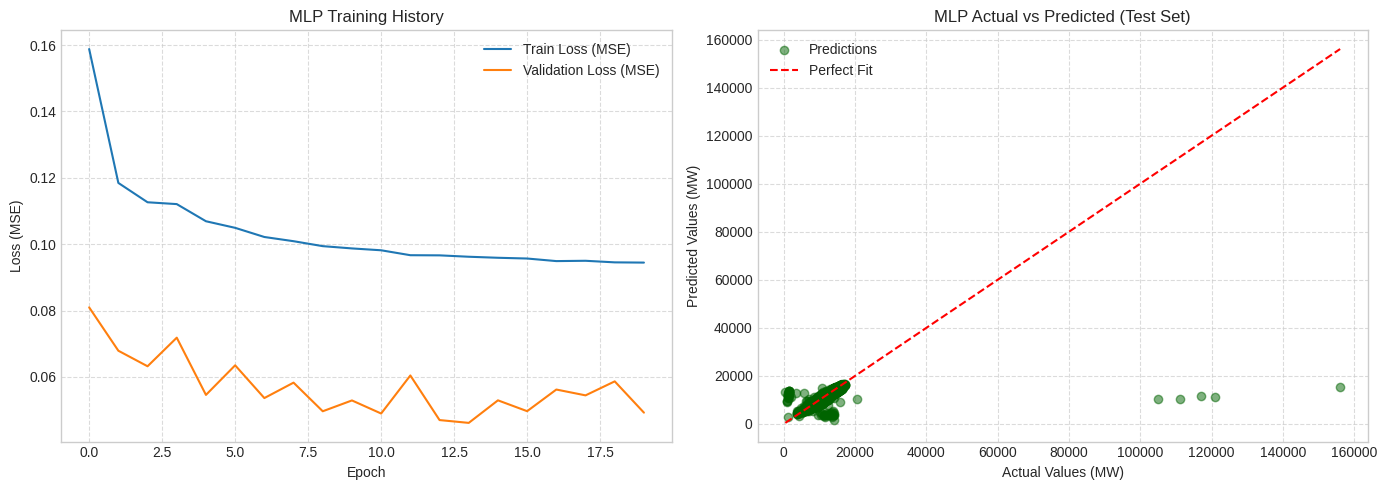

In [ ]:
print("\n" + "=" * 50)
print("SECTION 10: MULTI-LAYER PERCEPTRON (MLP)")
print("=" * 50)


# Build the MLP model (Uses standard 2D feature matrix)
mlp_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='linear'),
])

mlp_model.compile(optimizer='adam', loss='mse')

# Train the model (Without Early Stopping)
history_mlp = mlp_model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=0,
)


# PREDICT ON VALIDATION SET

mlp_preds_val_scaled = mlp_model.predict(X_val_scaled, verbose=0)
mlp_preds_val = scaler_y.inverse_transform(mlp_preds_val_scaled).flatten()

mlp_val_rmse = np.sqrt(mean_squared_error(y_val, mlp_preds_val))
mlp_val_r2 = r2_score(y_val, mlp_preds_val)

val_performance['MLP'] = mlp_val_rmse
print(f"MLP Training Complete.")
print(
    f"Validation RMSE: {mlp_val_rmse:.2f} MW | Validation R^2:"
    f" {mlp_val_r2:.4f}"
)


# PREDICT ON TEST SET

mlp_preds_test_scaled = mlp_model.predict(X_test_scaled, verbose=0)
mlp_preds_test = scaler_y.inverse_transform(mlp_preds_test_scaled).flatten()

mlp_test_rmse = np.sqrt(mean_squared_error(y_test, mlp_preds_test))
mlp_test_r2 = r2_score(y_test, mlp_preds_test)

print(
    f"Test RMSE:       {mlp_test_rmse:.2f} MW | Test R^2:      "
    f" {mlp_test_r2:.4f}"
)


# VISUALIZATIONS: EPOCH GRAPH & ACTUAL VS PREDICTED

plt.figure(figsize=(14, 5))

# 1. Epoch Graph (Learning Curve)
plt.subplot(1, 2, 1)
plt.plot(history_mlp.history['loss'], label='Train Loss (MSE)')
plt.plot(history_mlp.history['val_loss'], label='Validation Loss (MSE)')
plt.title('MLP Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 2. Actual vs Predicted Graph (Test Set)
plt.subplot(1, 2, 2)
plt.scatter(
    y_test, mlp_preds_test, alpha=0.5, color='darkgreen', label='Predictions'
)

# Plot the perfect prediction diagonal line
min_val = min(np.min(y_test), np.min(mlp_preds_test))
max_val = max(np.max(y_test), np.max(mlp_preds_test))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Fit')

plt.title('MLP Actual vs Predicted (Test Set)')
plt.xlabel('Actual Values (MW)')
plt.ylabel('Predicted Values (MW)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

RNN


SECTION 11: RECURRENT NEURAL NETWORK (RNN)
RNN Training Complete.
Validation RMSE: 439.83 MW | Validation R^2: 0.9561
Test RMSE:       1665.20 MW | Test R^2:       0.6425


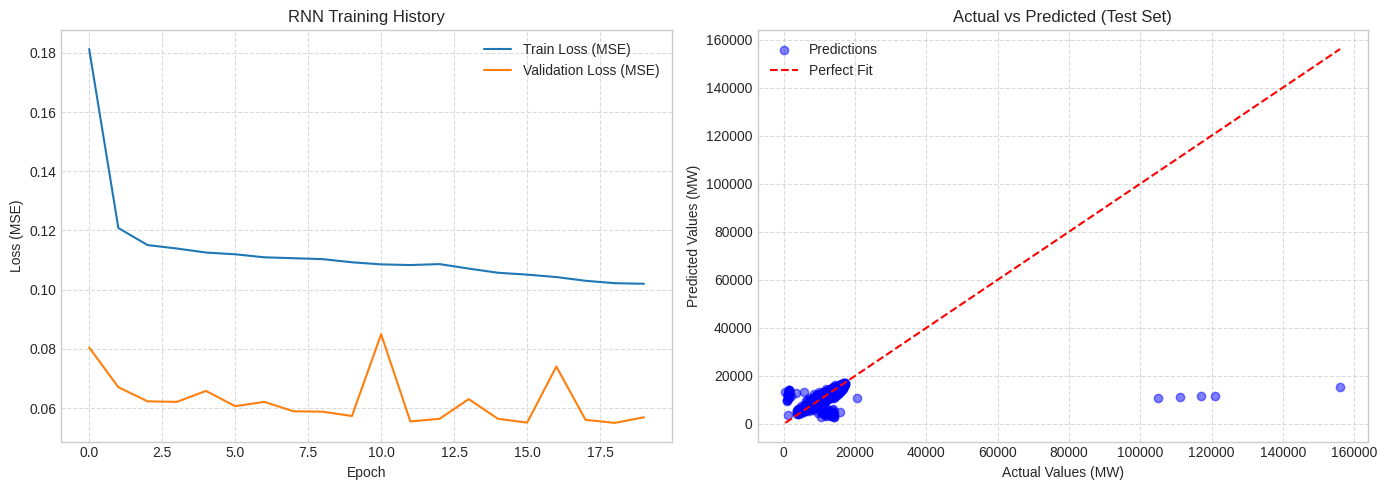

In [ ]:
print("\n" + "="*50)
print("SECTION 11: RECURRENT NEURAL NETWORK (RNN)")
print("="*50)

# Reshape data for RNN (Samples, Timesteps, Features)
X_train_rnn = np.expand_dims(X_train_scaled.values, axis=1)
X_val_rnn = np.expand_dims(X_val_scaled.values, axis=1)
X_test_rnn = np.expand_dims(X_test_scaled.values, axis=1)

# Build the model
rnn_model = Sequential([
    Input(shape=(X_train_rnn.shape[1], X_train_rnn.shape[2])),
    SimpleRNN(32, activation='relu', input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2])),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

rnn_model.compile(optimizer='adam', loss='mse')

# Train the model
history = rnn_model.fit(
    X_train_rnn, y_train_scaled,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_rnn, y_val_scaled),
    verbose=0
)


# PREDICT ON VALIDATION SET

rnn_preds_val_scaled = rnn_model.predict(X_val_rnn, verbose=0)
rnn_preds_val = scaler_y.inverse_transform(rnn_preds_val_scaled).flatten()

rnn_val_rmse = np.sqrt(mean_squared_error(y_val, rnn_preds_val))
rnn_val_r2 = r2_score(y_val, rnn_preds_val) # Added R^2

val_performance['RNN'] = rnn_val_rmse
print(f"RNN Training Complete.")
print(f"Validation RMSE: {rnn_val_rmse:.2f} MW | Validation R^2: {rnn_val_r2:.4f}")


# PREDICT ON TEST SET

rnn_preds_test_scaled = rnn_model.predict(X_test_rnn, verbose=0)
rnn_preds_test = scaler_y.inverse_transform(rnn_preds_test_scaled).flatten()

rnn_test_rmse = np.sqrt(mean_squared_error(y_test, rnn_preds_test))
rnn_test_r2 = r2_score(y_test, rnn_preds_test) # Added R^2

print(f"Test RMSE:       {rnn_test_rmse:.2f} MW | Test R^2:       {rnn_test_r2:.4f}")


# VISUALIZATIONS: EPOCH GRAPH & ACTUAL VS PREDICTED

plt.figure(figsize=(14, 5))

# 1. Epoch Graph (Learning Curve)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('RNN Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 2. Actual vs Predicted Graph (Test Set)
plt.subplot(1, 2, 2)
plt.scatter(y_test, rnn_preds_test, alpha=0.5, color='blue', label='Predictions')

# Plot the perfect prediction diagonal line
min_val = min(np.min(y_test), np.min(rnn_preds_test))
max_val = max(np.max(y_test), np.max(rnn_preds_test))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Fit')

plt.title('Actual vs Predicted (Test Set)')
plt.xlabel('Actual Values (MW)')
plt.ylabel('Predicted Values (MW)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Model Comparison


SECTION 11: FINAL MODEL COMPARISON ON TEST SET (2023-2026)


,Model,Val RMSE (MW),Test RMSE (MW),Test MAE (MW),Test R² Score
0,RNN,439.833456,1665.200063,487.872253,0.642469
1,MLP,409.273098,1692.422746,573.591675,0.630683
2,Linear Regression,523.430373,1977.332516,495.059109,0.495872
3,XGBoost,530.617329,2022.336087,951.059082,0.472663
4,Random Forest,610.888043,2069.432374,1010.749690,0.447816


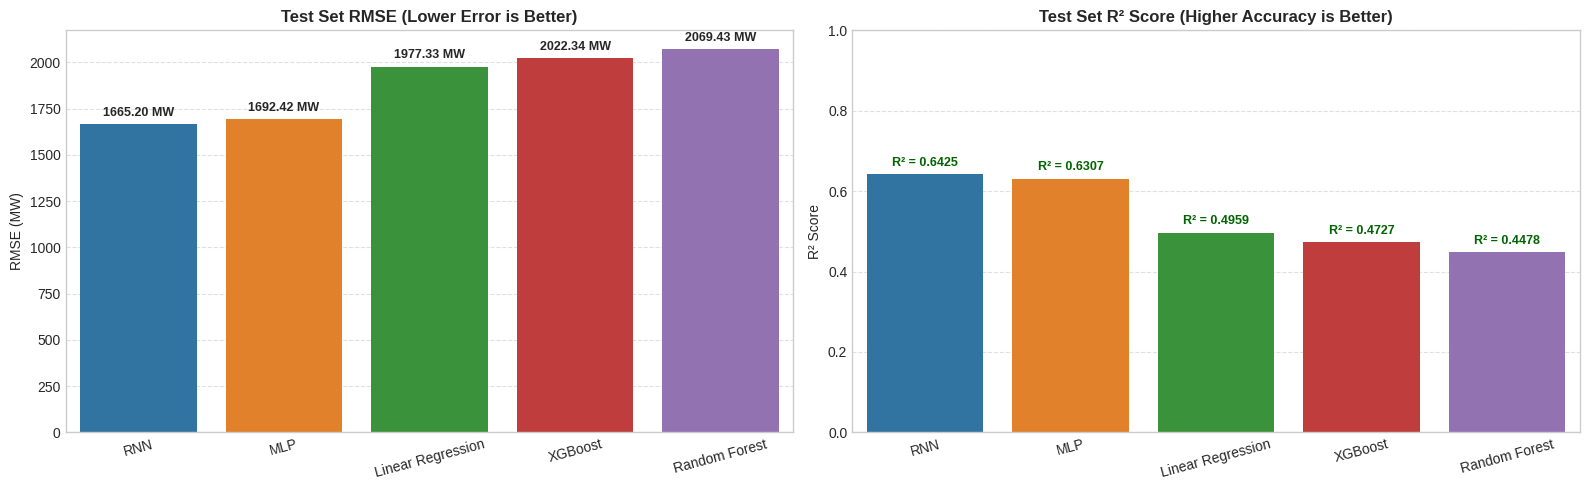

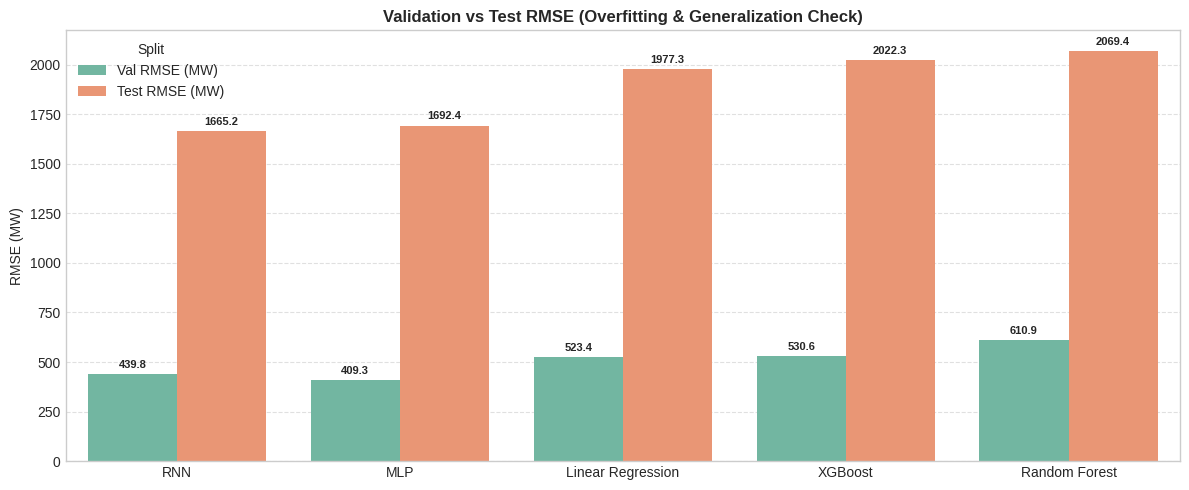

In [ ]:
# ==============================================================================
# SECTION 12: FINAL MODEL COMPARISON & VISUALIZATIONS
# ==============================================================================
print("\n" + "="*50)
print("SECTION 11: FINAL MODEL COMPARISON ON TEST SET (2023-2026)")
print("="*50)

# 1. Calculate Test MAE metrics (Included MLP for 5-model evaluation)
lr_test_mae = mean_absolute_error(y_test, lr_preds_test)
rf_test_mae = mean_absolute_error(y_test, rf_preds_test)
xgb_test_mae = mean_absolute_error(y_test, xgb_preds_test)
rnn_test_mae = mean_absolute_error(y_test, rnn_preds_test)
mlp_test_mae = mean_absolute_error(y_test, mlp_preds_test)

# 2. Build Master Comparison DataFrame
comparison_dict = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'RNN', 'MLP'],
    'Val RMSE (MW)': [lr_val_rmse, rf_val_rmse, xgb_val_rmse, rnn_val_rmse, mlp_val_rmse],
    'Test RMSE (MW)': [lr_test_rmse, rf_test_rmse, xgb_test_rmse, rnn_test_rmse, mlp_test_rmse],
    'Test MAE (MW)': [lr_test_mae, rf_test_mae, xgb_test_mae, rnn_test_mae, mlp_test_mae],
    'Test R² Score': [lr_test_r2, rf_test_r2, xgb_test_r2, rnn_test_r2, mlp_test_r2]
}

df_comparison = pd.DataFrame(comparison_dict).sort_values(by='Test RMSE (MW)').reset_index(drop=True)
display(df_comparison)

# 5 distinct custom colors for 5 models
model_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# ------------------------------------------------------------------------------
# GRAPH 1: TEST RMSE & TEST R² SCORE SIDE-BY-SIDE BAR CHARTS
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Test RMSE (Lower is Better)
sns.barplot(
    data=df_comparison,
    x='Model',
    y='Test RMSE (MW)',
    ax=axes[0],
    hue='Model',
    palette=model_colors,
    legend=False
)
axes[0].set_title('Test Set RMSE (Lower Error is Better)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE (MW)', fontsize=10)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(
            f'{height:.2f} MW',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom', fontsize=9, fontweight='bold',
            xytext=(0, 4), textcoords='offset points'
        )

# Plot 2: Test R² Score (Higher is Better)
sns.barplot(
    data=df_comparison,
    x='Model',
    y='Test R² Score',
    ax=axes[1],
    hue='Model',
    palette=model_colors,
    legend=False
)
axes[1].set_title('Test Set R² Score (Higher Accuracy is Better)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R² Score', fontsize=10)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
axes[1].set_ylim(0, max(1.0, df_comparison['Test R² Score'].max() * 1.15))
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

for p in axes[1].patches:
    height = p.get_height()
    axes[1].annotate(
        f'R² = {height:.4f}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom', fontsize=9, fontweight='bold', color='darkgreen',
        xytext=(0, 4), textcoords='offset points'
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# GRAPH 2: VALIDATION VS TEST RMSE (OVERFITTING ANALYSIS)
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 5))

df_melted = df_comparison.melt(
    id_vars='Model',
    value_vars=['Val RMSE (MW)', 'Test RMSE (MW)'],
    var_name='Dataset Split',
    value_name='RMSE (MW)'
)

ax2 = sns.barplot(data=df_melted, x='Model', y='RMSE (MW)', hue='Dataset Split', palette='Set2')
plt.title('Validation vs Test RMSE (Overfitting & Generalization Check)', fontsize=12, fontweight='bold')
plt.ylabel('RMSE (MW)', fontsize=10)
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Split')

# Value annotations for direct split comparison
for p in ax2.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax2.annotate(
            f'{height:.1f}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom', fontsize=8, fontweight='bold',
            xytext=(0, 3), textcoords='offset points'
        )

plt.tight_layout()
plt.show()